# Witness My Entanglement — Full Pipeline Showcase

**Goal**: certify Genuine Multipartite Entanglement on as many qubits as possible on IQM Emerald, in a single end-to-end run.

## Approach in one diagram

```
┌──────────────────────────────────────────────┐
│ 1. Pull live calibration                     │  per-qubit T1/T2/RO/1Q,
│    (no hardware time)                        │  per-edge CZ fidelity
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 2. Threshold filter for stability             │  exclude qubits with
│    (no hardware time)                         │  marginal calibration
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 3. Comprehensive edge cost                    │  CZ + T1 + T2 + 1Q
│    w(u,v) = (1−F_CZ) + decoherence + 1Q       │  (RO excluded — QREM
│                                                │   handles it)
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 4. Multi-start Prim's + local search          │  best n-qubit
│                                                │  spanning tree
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 5. A-priori predict ⟨g_i⟩ and W               │  decide before
│    if predW > n−1: certification is feasible  │  burning shots
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 6. Hardware: 2 circuits per tree              │  IQM Emerald,
│    setting A (black→X), setting B (white→X)   │  1500 shots/circuit
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 7. Compute W and apply parity-QREM            │  per-qubit RO
│    c_i = 1/(P(0|0) + P(1|1) − 1)              │  correction factors
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 8. Verdict: W > n−1 ⟹ GME at significance σ   │
└──────────────────────────────────────────────┘
```

## Theory

For any connected 2-colorable graph state |G⟩ with stabilizers $g_i = X_i \otimes \bigotimes_{j \in N(i)} Z_j$:

$$W = \sum_i \langle g_i \rangle \;\;\;\;\;\; W \le n-1 \;\Longleftrightarrow\; \text{biseparable}$$

Therefore $W > n-1 \Rightarrow$ **Genuine Multipartite Entanglement** (Tóth & Gühne 2005).

**Why a spanning tree**: minimum n−1 edges → minimum CZ gates → minimum prep error. The bound n−1 is invariant in graph density, so denser graphs only add noise without strengthening the certificate.

## Why a spanning tree? Empirical proof

Before running on hardware, let's settle a recurring question: **does adding more edges to the graph give a stronger GME certificate?**

The Tóth-Gühne witness $W = \sum_i \langle g_i \rangle \le n-1$ has the same theoretical bound for **any** connected 2-colorable graph state — tree, 2D cluster, or complete bipartite. So denser graphs offer no theoretical advantage. But under noise?

We compare three different graph topologies on the same 8 qubits with identical noise (CZ 97.5%, 1Q 99.5%):

C:\Users\david\Documents\iqm_hackathon\.venv\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


C:\Users\david\Documents\iqm_hackathon\.venv\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


          graph  edges  W_ideal  W_noisy   g_mean GME
    tree (path)      7      8.0   7.4330 0.929125   ✓
  2D grid (2x4)     10      8.0   7.0315 0.878938   ✓
complete K(4,4)     16      8.0   6.2725 0.784063   ✗


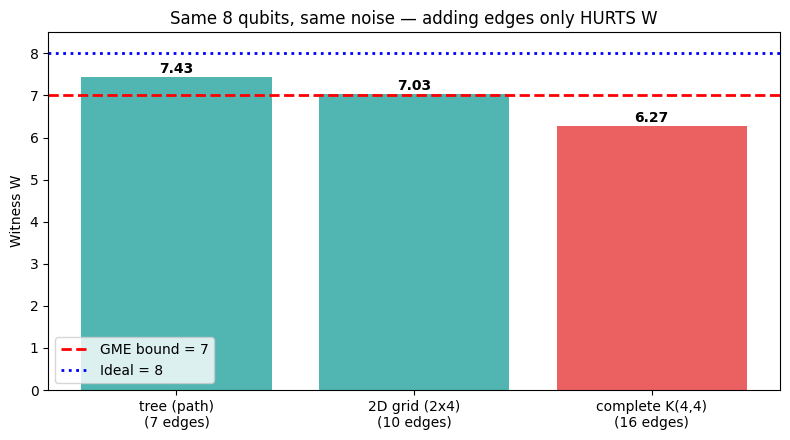


Conclusion: tree (n-1 edges) is provably optimal for our witness.
More edges = more CZ gates = more error, with no theoretical upside.


In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from src.circuits.graph_state import build_graph_state, two_coloring
from src.witnesses.gme_graph import build_gme_circuits_graph, compute_gme_witness_graph

# Realistic IQM-like noise model
nm = NoiseModel()
nm.add_all_qubit_quantum_error(depolarizing_error(0.005, 1), ['h', 'rx', 'ry', 'rz', 'sx'])
nm.add_all_qubit_quantum_error(depolarizing_error(0.025, 2), ['cz'])
sim = AerSimulator(noise_model=nm)

n_demo = 8
shots_demo = 4000
candidates = {
    'tree (path)':       [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7)],
    '2D grid (2x4)':     [(0,1),(1,2),(2,3),(0,4),(1,5),(2,6),(3,7),(4,5),(5,6),(6,7)],
    'complete K(4,4)':   [(i, j) for i in range(4) for j in range(4, 8)],
}

rows = []
for name, edges in candidates.items():
    coloring = two_coloring(n_demo, edges)
    state = build_graph_state(n_demo, edges)
    circ_a, circ_b = build_gme_circuits_graph(state, coloring)
    circs = transpile([circ_a, circ_b], sim, basis_gates=['rx','ry','rz','sx','h','cz'],
                      optimization_level=0)
    res = sim.run(circs, shots=shots_demo).result()
    cA, cB = res.get_counts(0), res.get_counts(1)
    out = compute_gme_witness_graph(cA, cB, n_demo, edges, coloring)
    g_mean = float(np.mean(list(out['stabilizer_values'].values())))
    rows.append({'graph': name, 'edges': len(edges), 'W_ideal': out['W_ideal'],
                 'W_noisy': out['W'], 'g_mean': g_mean,
                 'GME': '✓' if out['is_gme'] else '✗'})

import pandas as pd
print(pd.DataFrame(rows).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4.5))
names = [r['graph'] for r in rows]
edge_counts = [r['edges'] for r in rows]
W_vals = [r['W_noisy'] for r in rows]
colors = ['#32a8a4' if r['GME'] == '✓' else '#e84545' for r in rows]
ax.bar(range(len(rows)), W_vals, color=colors, alpha=0.85,
        tick_label=[f'{n}\n({e} edges)' for n, e in zip(names, edge_counts)])
ax.axhline(n_demo - 1, color='red', linestyle='--', linewidth=2, label=f'GME bound = {n_demo-1}')
ax.axhline(n_demo, color='blue', linestyle=':', linewidth=2, label=f'Ideal = {n_demo}')
for i, v in enumerate(W_vals):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
ax.set_ylabel('Witness W')
ax.set_title(f'Same {n_demo} qubits, same noise — adding edges only HURTS W')
ax.legend(loc='lower left'); ax.set_ylim(0, n_demo + 0.5)
plt.tight_layout()
plt.savefig('showcase_density_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nConclusion: tree (n-1 edges) is provably optimal for our witness.')
print('More edges = more CZ gates = more error, with no theoretical upside.')

In [2]:
import sys, time
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import (
    get_backend, is_simulator,
    get_qubit_metrics, filter_qubits_by_metrics,
    select_best_tree, predict_stabilizer_fidelities,
)
from src.circuits.graph_state import build_graph_state, neighbours_from_edges
from src.witnesses.gme_graph import (
    build_gme_circuits_graph, compute_gme_witness_graph, gme_significance_graph,
)
from src.mitigation.parity_qrem import (
    correction_factors_from_metrics, apply_qrem_to_stabilizers_graph,
)
from src.mitigation.zne import (
    fold_cz_gates, extrapolate_to_zero_noise, extrapolate_with_bootstrap,
)
from src.visualization import plot_device_topology, _device_layout

TARGET_NS = [6, 8, 12, 16, 20]
SCALES = [1, 3, 5]
SHOTS = 1500

backend = get_backend(device='emerald')
print(f'Backend: {backend} (hardware: {not is_simulator(backend)})')
print(f'Sweep: n = {TARGET_NS}, scales = {SCALES}, shots/circuit = {SHOTS}')
print(f'Mitigation combinations evaluated per n: raw, +QREM, +ZNE, +QREM+ZNE')

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x00000285967A3F80> (hardware: True)
Sweep: n = [6, 8, 12, 16, 20], scales = [1, 3, 5], shots/circuit = 1500
Mitigation combinations evaluated per n: raw, +QREM, +ZNE, +QREM+ZNE


## Step 1 — Pull live calibration data

All metrics come from a single REST call to the IQM Resonance API (`get_quality_metric_set`). No hardware time used.

Qubits with metrics: 54
CZ pairs reported : 81


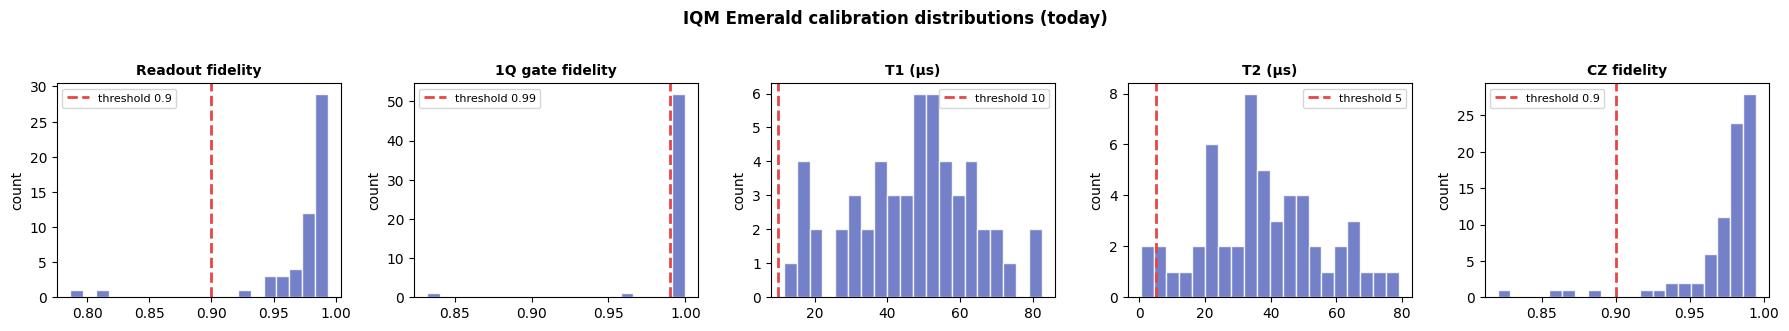

In [3]:
qm, cz = get_qubit_metrics(backend)
print(f'Qubits with metrics: {len(qm)}')
print(f'CZ pairs reported : {len(cz)}')

# Distributions
ro = [m.get('readout_fidelity', 0) for m in qm.values()]
f1 = [m.get('one_q_fidelity', 0) for m in qm.values()]
t1 = [m.get('t1', 0) * 1e6 for m in qm.values() if m.get('t1')]
t2 = [m.get('t2', 0) * 1e6 for m in qm.values() if m.get('t2')]
cz_vals = list(cz.values())

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, vals, title, threshold in zip(
    axes,
    [ro, f1, t1, t2, cz_vals],
    ['Readout fidelity', '1Q gate fidelity', 'T1 (µs)', 'T2 (µs)', 'CZ fidelity'],
    [0.90, 0.99, 10, 5, 0.90],
):
    ax.hist(vals, bins=20, color='#5c6bc0', alpha=0.85, edgecolor='white')
    ax.axvline(threshold, color='#e84545', linestyle='--', linewidth=2, label=f'threshold {threshold}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.suptitle('IQM Emerald calibration distributions (today)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 2 — Threshold filter for stability

Empirically, qubits with marginal calibration drift more than headline metrics suggest. The threshold filter excludes them before optimization. Default thresholds:

- Readout fidelity ≥ 0.90
- 1Q gate fidelity ≥ 0.99
- T1 ≥ 10 µs
- T2 ≥ 5 µs
- Best CZ partner fidelity ≥ 0.90

In [4]:
good = filter_qubits_by_metrics(qm, cz)
excluded = sorted(set(range(backend.num_qubits)) - good)
print(f'Qubits passing thresholds: {len(good)}/{backend.num_qubits}')
print(f'Excluded qubits (with reasons):')
for idx in excluded:
    m = qm.get(idx, {})
    fails = []
    if m.get('readout_fidelity', 0) < 0.90: fails.append(f"RO={m.get('readout_fidelity', 0):.3f}")
    if m.get('one_q_fidelity', 0) < 0.99: fails.append(f"1Q={m.get('one_q_fidelity', 0):.4f}")
    if (m.get('t1') or 0) < 10e-6: fails.append(f"T1={m.get('t1', 0)*1e6:.0f}µs")
    if (m.get('t2') or 0) < 5e-6: fails.append(f"T2={m.get('t2', 0)*1e6:.0f}µs")
    pairs = [v for k, v in cz.items() if idx in k]
    best_cz = max(pairs) if pairs else 0
    if best_cz < 0.90: fails.append(f"best_CZ={best_cz:.3f}")
    print(f'  QB{idx+1:>2}: {fails}')

Qubits passing thresholds: 50/54
Excluded qubits (with reasons):
  QB19: ['T2=3µs']
  QB28: ['T2=0µs', 'best_CZ=0.000']
  QB43: ['RO=0.810', '1Q=0.9610', 'best_CZ=0.889']
  QB46: ['RO=0.786', '1Q=0.8319', 'T2=0µs', 'best_CZ=0.000']


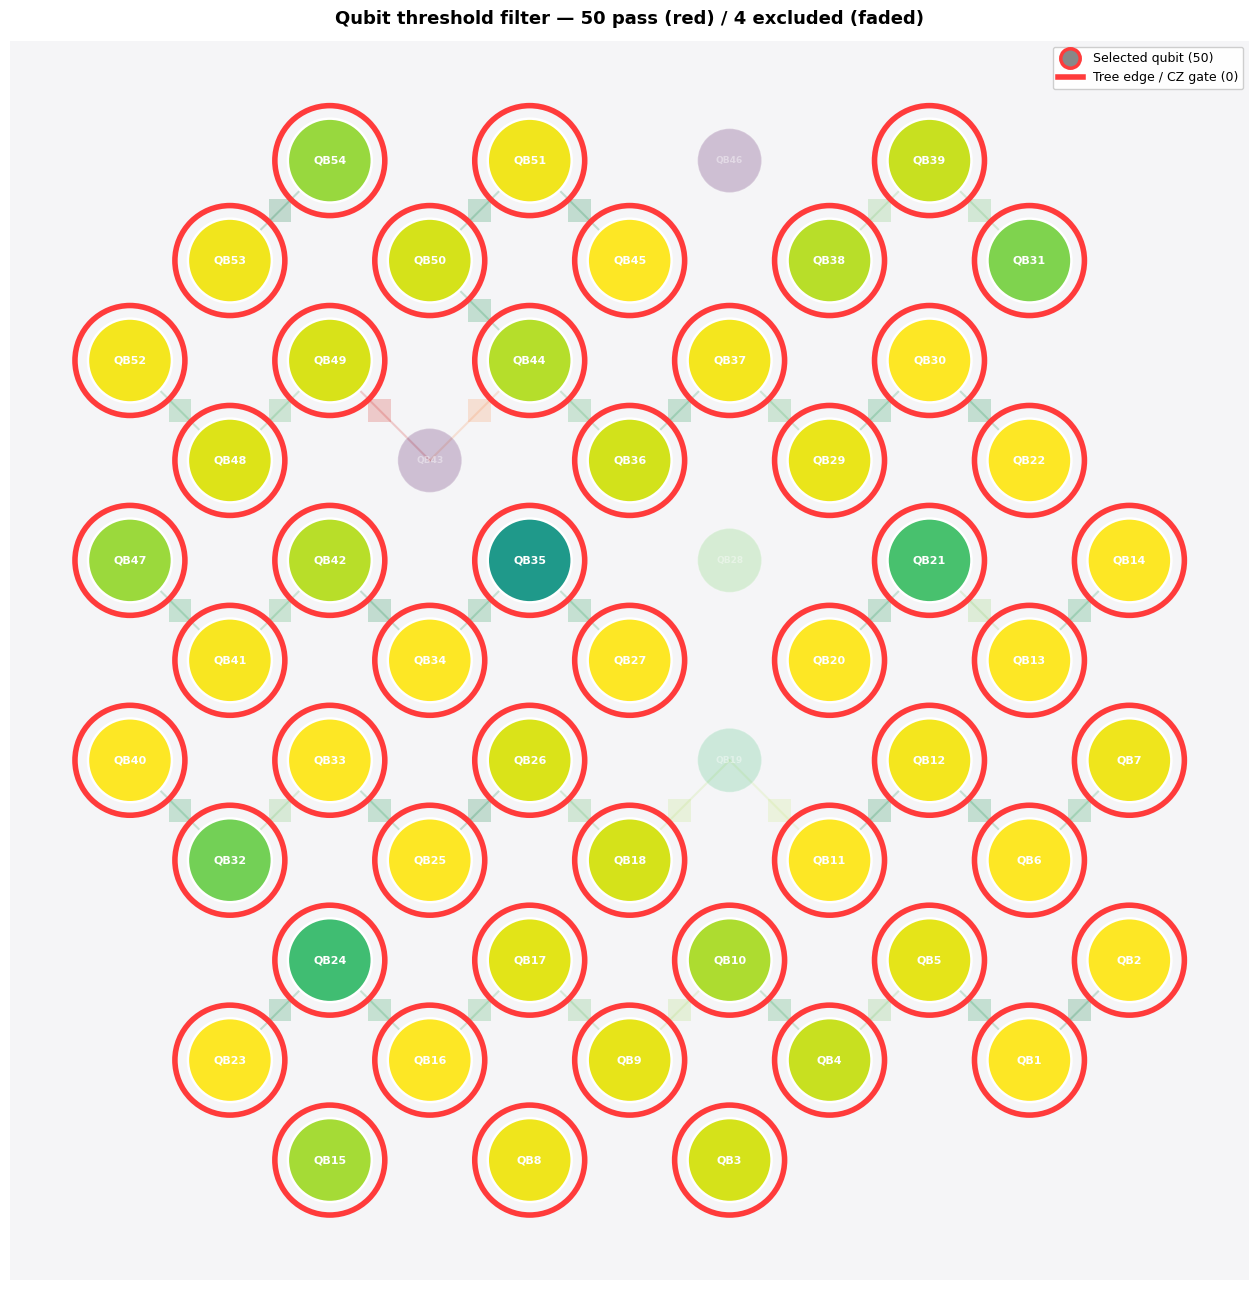

In [5]:
# Visualise which qubits passed / failed on the chip topology
fig, ax = plt.subplots(figsize=(13, 13))
plot_device_topology(
    backend, metrics=qm, cz_fidelities=cz, color_by='readout_fidelity',
    highlight_qubits=sorted(good),
    title=f'Qubit threshold filter — {len(good)} pass (red) / {len(excluded)} excluded (faded)',
    ax=ax, spotlight=True,
)
plt.tight_layout()
plt.savefig('showcase_filter.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3-5 — Build edge cost, run Prim's, predict W

For each target n, find the lowest-cost spanning tree on the surviving qubits, and predict the per-stabilizer fidelity.

In [6]:
trees = {}
for n in TARGET_NS:
    t = select_best_tree(backend, n)
    trees[n] = t
    pw = t['predicted_W']
    bound = n - 1
    margin = pw / n - (n - 1) / n
    verdict = '✓ feasible' if pw > bound else '✗ predicted to fail'
    print(f'n = {n:2d}:  cost={t["weight"]:.4f}  predicted W = {pw:.3f} / {n}  '
          f'(threshold {bound}, margin {margin:+.4f})  {verdict}')
    print(f'         qubits: {t["qubits"]}')

n =  6:  cost=0.0971  predicted W = 5.729 / 6  (threshold 5, margin +0.1216)  ✓ feasible
         qubits: [46, 47, 48, 51, 52, 53]


n =  8:  cost=0.1440  predicted W = 7.576 / 8  (threshold 7, margin +0.0720)  ✓ feasible
         qubits: [33, 41, 46, 47, 48, 51, 52, 53]


n = 12:  cost=0.2327  predicted W = 11.311 / 12  (threshold 11, margin +0.0259)  ✓ feasible
         qubits: [23, 24, 25, 32, 33, 41, 46, 47, 48, 51, 52, 53]


n = 16:  cost=0.3351  predicted W = 14.986 / 16  (threshold 15, margin -0.0009)  ✗ predicted to fail
         qubits: [16, 17, 22, 23, 24, 25, 26, 32, 33, 41, 46, 47, 48, 51, 52, 53]


n = 20:  cost=0.4427  predicted W = 18.656 / 20  (threshold 19, margin -0.0172)  ✗ predicted to fail
         qubits: [15, 16, 17, 22, 23, 24, 25, 26, 32, 33, 34, 35, 36, 41, 46, 47, 48, 51, 52, 53]


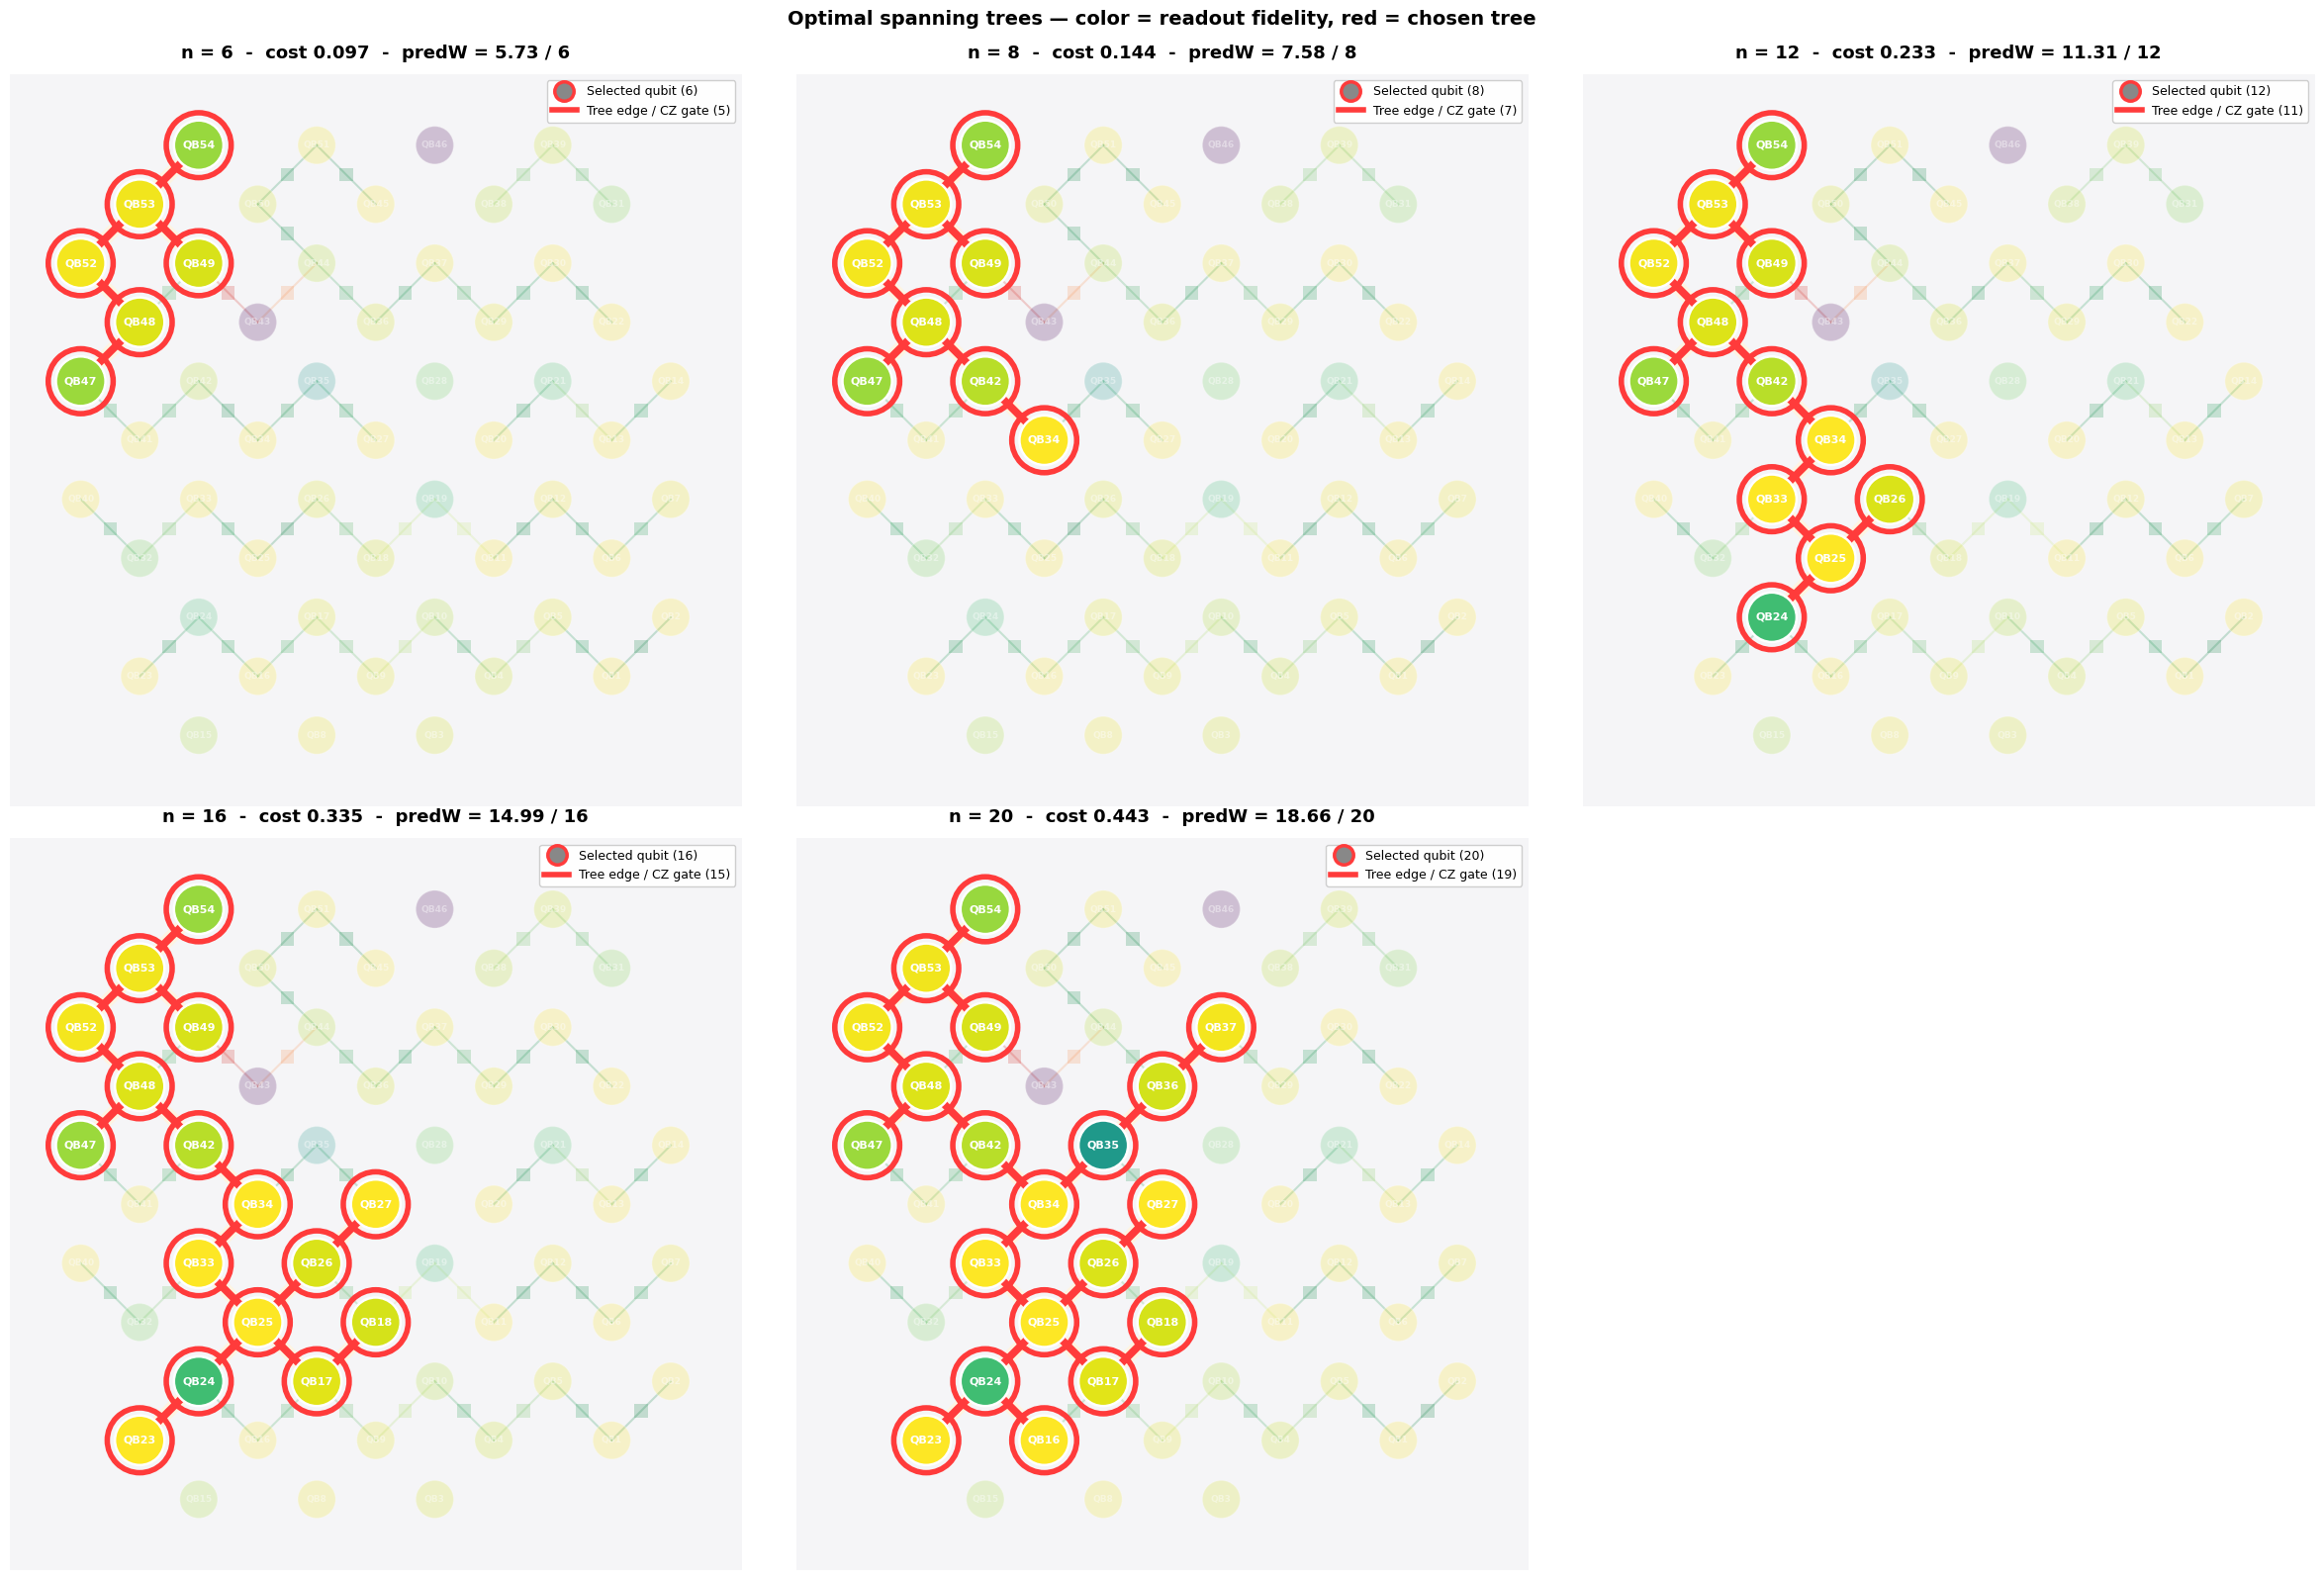

In [7]:
# Visualise each chosen tree on the chip topology (exact IQM dashboard layout).
# IMPORTANT: tree['edges'] is in PHYSICAL qubit indices (what plot expects).
# tree['logical_edges'] is in 0..n-1 logical indices and would be wrong here.
n_trees = len(trees)
ncols = min(n_trees, 3)
nrows = (n_trees + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 8*nrows), squeeze=False)
for ax, (n, t) in zip(axes.flat, trees.items()):
    pw = t['predicted_W']
    plot_device_topology(
        backend, metrics=qm, cz_fidelities=cz, color_by='readout_fidelity',
        highlight_qubits=t['qubits'],
        highlight_edges=t['edges'],   # physical edges
        title=f'n = {n}  -  cost {t["weight"]:.3f}  -  predW = {pw:.2f} / {n}',
        ax=ax, spotlight=True,
    )
# Hide unused axes
for ax in axes.flat[len(trees):]:
    ax.set_visible(False)
plt.suptitle('Optimal spanning trees — color = readout fidelity, red = chosen tree',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('showcase_trees.png', dpi=110, bbox_inches='tight')
plt.show()

## Step 6 — Comprehensive hardware sweep: every n × every mitigation

For each target n, build CZ-folded circuits at scales 1, 3, 5 (3× and 5× the gate noise via CZ folding for ZNE). All circuits — `len(N) × |scales| × 2 settings` — go into a SINGLE IQM job, so all of them share the same calibration window (drift-fair comparison).

Then for each n we compute four W values:
- **raw** (scale=1, no mitigation)
- **+QREM** (scale=1, parity-QREM applied)
- **+ZNE** (linear extrapolation across scales 1, 3, 5)
- **+QREM+ZNE** (both: QREM at each scale, then ZNE)

Bootstrap σ on each (resample shot counts; refit; report std of extrapolated W).

In [8]:
correction_factors = correction_factors_from_metrics(qm) if not is_simulator(backend) else {}

# Build all circuits for all (n, scale) combinations — submit as ONE job
all_circuits = []
descriptors = []   # parallel array: descriptors[i] = (n, scale, 'a'|'b', tree)
for n in TARGET_NS:
    t = trees[n]
    state = build_graph_state(n, t['logical_edges'])
    circ_a, circ_b = build_gme_circuits_graph(state, t['coloring'])
    for s in SCALES:
        fa = fold_cz_gates(circ_a, s)
        fb = fold_cz_gates(circ_b, s)
        transpiled = transpile([fa, fb], backend=backend,
                                initial_layout=t['qubits'], optimization_level=3)
        all_circuits.extend(transpiled)
        descriptors.append((n, s, 'a', t))
        descriptors.append((n, s, 'b', t))

print(f'Total circuits in job: {len(all_circuits)} '
      f'(= {len(TARGET_NS)} sizes × {len(SCALES)} scales × 2 settings)')

t0 = time.time()
job = backend.run(all_circuits, shots=SHOTS)
try: print(f'Job ID: {job.job_id()}')
except Exception: pass
counts_list = job.result().get_counts()
print(f'Done in {time.time()-t0:.1f}s')

Total circuits in job: 30 (= 5 sizes × 3 scales × 2 settings)


Job ID: 019e0dff-bd29-7580-933e-27a975a1c733


Done in 150.9s


In [9]:
# Group counts by (n, scale) → process every mitigation combination per n
counts_by = {}   # (n, scale) -> {'a': dict, 'b': dict}
for i, (n, s, ab, t) in enumerate(descriptors):
    counts_by.setdefault((n, s), {})[ab] = counts_list[i]

results = []
for n in TARGET_NS:
    t = trees[n]
    edges = t['logical_edges']; coloring = t['coloring']; qubits = t['qubits']
    nbrs = neighbours_from_edges(n, edges)

    # Per-scale: raw + QREM W
    counts_a_per_scale = [counts_by[(n, s)]['a'] for s in SCALES]
    counts_b_per_scale = [counts_by[(n, s)]['b'] for s in SCALES]

    W_raw_per_scale, W_qrem_per_scale = [], []
    for cA, cB in zip(counts_a_per_scale, counts_b_per_scale):
        res_s = compute_gme_witness_graph(cA, cB, n, edges, coloring)
        W_raw_per_scale.append(res_s['W'])
        stab_q = apply_qrem_to_stabilizers_graph(
            res_s['stabilizer_values'], n, edges, qubits, correction_factors)
        W_qrem_per_scale.append(sum(stab_q.values()))

    # Bootstrap σ for each mitigation
    bs_raw = extrapolate_with_bootstrap(
        SCALES, counts_a_per_scale, counts_b_per_scale, n, edges, coloring,
        correction_factors=None, layout=None, method='linear', n_bootstrap=200)
    bs_qrem_zne = extrapolate_with_bootstrap(
        SCALES, counts_a_per_scale, counts_b_per_scale, n, edges, coloring,
        correction_factors=correction_factors, layout=qubits,
        method='linear', n_bootstrap=200)

    # Single-scale (=1) bootstrap σ for raw and +QREM
    bs_raw_s1 = extrapolate_with_bootstrap(
        [1], [counts_a_per_scale[0]], [counts_b_per_scale[0]], n, edges, coloring,
        correction_factors=None, layout=None, method='linear', n_bootstrap=200,
    ) if False else None   # bootstrap from a single point isn't meaningful; use shot-noise formula

    # For single-scale W use simple shot-noise σ (each W is from one circuit set)
    # std(W) ≈ √n / √shots
    sn_std = np.sqrt(n) / np.sqrt(SHOTS)

    bound = n - 1
    W_raw_s1  = W_raw_per_scale[0]
    W_qrem_s1 = W_qrem_per_scale[0]
    W_zne     = bs_raw['W_zne_mean']
    W_qz      = bs_qrem_zne['W_zne_mean']

    sigma_raw_s1  = (W_raw_s1  - bound) / sn_std
    sigma_qrem_s1 = (W_qrem_s1 - bound) / sn_std
    sigma_zne     = bs_raw['sigma_above_bound']
    sigma_qz      = bs_qrem_zne['sigma_above_bound']

    results.append({
        'n': n, 'qubits': qubits, 'logical_edges': edges, 'coloring': coloring,
        'tree_cost': t['weight'],
        'predicted_W': t['predicted_W'],
        'W_raw': W_raw_s1,    'sigma_raw': sigma_raw_s1,
        'W_qrem': W_qrem_s1,  'sigma_qrem': sigma_qrem_s1,
        'W_zne': W_zne,       'sigma_zne': sigma_zne, 'W_zne_std': bs_raw['W_zne_std'],
        'W_qz': W_qz,         'sigma_qz': sigma_qz,   'W_qz_std': bs_qrem_zne['W_zne_std'],
        'bound': bound,
        'is_gme_raw':  W_raw_s1  > bound,
        'is_gme_qrem': W_qrem_s1 > bound,
        'is_gme_zne':  W_zne     > bound,
        'is_gme_qz':   W_qz      > bound,
        'W_raw_per_scale':  W_raw_per_scale,
        'W_qrem_per_scale': W_qrem_per_scale,
    })
    print(f'\nn={n:>2}  bound={bound}')
    print(f'  raw      : W = {W_raw_s1:6.3f}   σ = {sigma_raw_s1:+6.2f}   '
          f'GME = {"YES" if W_raw_s1>bound else "no"}')
    print(f'  +QREM    : W = {W_qrem_s1:6.3f}   σ = {sigma_qrem_s1:+6.2f}   '
          f'GME = {"YES" if W_qrem_s1>bound else "no"}')
    print(f'  +ZNE     : W = {W_zne:6.3f} ±{bs_raw["W_zne_std"]:.2f}  σ = {sigma_zne:+6.2f}   '
          f'GME = {"YES" if W_zne>bound else "no"}')
    print(f'  +QREM+ZNE: W = {W_qz:6.3f} ±{bs_qrem_zne["W_zne_std"]:.2f}  σ = {sigma_qz:+6.2f}   '
          f'GME = {"YES" if W_qz>bound else "no"}')


n= 6  bound=5
  raw      : W =  5.415   σ =  +6.56   GME = YES
  +QREM    : W =  6.007   σ = +15.93   GME = YES
  +ZNE     : W =  5.692 ±0.04  σ = +15.81   GME = YES
  +QREM+ZNE: W =  6.321 ±0.05  σ = +27.18   GME = YES



n= 8  bound=7
  raw      : W =  7.179   σ =  +2.45   GME = YES
  +QREM    : W =  7.977   σ = +13.38   GME = YES
  +ZNE     : W =  7.564 ±0.05  σ = +11.17   GME = YES
  +QREM+ZNE: W =  8.418 ±0.06  σ = +25.00   GME = YES



n=12  bound=11
  raw      : W = 10.707   σ =  -3.28   GME = no
  +QREM    : W = 11.914   σ = +10.22   GME = YES
  +ZNE     : W = 11.559 ±0.06  σ =  +8.90   GME = YES
  +QREM+ZNE: W = 12.885 ±0.07  σ = +26.82   GME = YES



n=16  bound=15
  raw      : W = 12.363   σ = -25.54   GME = no
  +QREM    : W = 13.808   σ = -11.54   GME = no
  +ZNE     : W = 13.492 ±0.09  σ = -16.07   GME = no
  +QREM+ZNE: W = 15.091 ±0.10  σ =  +0.87   GME = YES



n=20  bound=19
  raw      : W = 15.835   σ = -27.41   GME = no
  +QREM    : W = 17.960   σ =  -9.01   GME = no
  +ZNE     : W = 17.223 ±0.11  σ = -15.73   GME = no
  +QREM+ZNE: W = 19.595 ±0.13  σ =  +4.56   GME = YES


## Step 8 — Results table

In [10]:
import pandas as pd
df = pd.DataFrame([
    {
        'n': r['n'], 'bound': r['bound'], 'predW': round(r['predicted_W'], 2),
        'W raw':       round(r['W_raw'], 2),  'σ raw':       round(r['sigma_raw'], 1),
        'W +QREM':     round(r['W_qrem'], 2), 'σ +QREM':     round(r['sigma_qrem'], 1),
        'W +ZNE':      round(r['W_zne'], 2),  'σ +ZNE':      round(r['sigma_zne'], 1),
        'W +QREM+ZNE': round(r['W_qz'], 2),   'σ +QREM+ZNE': round(r['sigma_qz'], 1),
        'GME raw':       '✓' if r['is_gme_raw']  else '✗',
        'GME +QREM':     '✓' if r['is_gme_qrem'] else '✗',
        'GME +ZNE':      '✓' if r['is_gme_zne']  else '✗',
        'GME +QREM+ZNE': '✓' if r['is_gme_qz']   else '✗',
    } for r in results
])
print(df.to_string(index=False))
print()
print('Max GME-certified n per mitigation:')
for key, label in [('is_gme_raw', 'raw       '),
                    ('is_gme_qrem', '+QREM     '),
                    ('is_gme_zne', '+ZNE      '),
                    ('is_gme_qz',  '+QREM+ZNE ')]:
    m = max((r['n'] for r in results if r[key]), default=0)
    print(f'  {label}: {m}')

 n  bound  predW  W raw  σ raw  W +QREM  σ +QREM  W +ZNE  σ +ZNE  W +QREM+ZNE  σ +QREM+ZNE GME raw GME +QREM GME +ZNE GME +QREM+ZNE
 6      5   5.73   5.41    6.6     6.01     15.9    5.69    15.8         6.32         27.2       ✓         ✓        ✓             ✓
 8      7   7.58   7.18    2.4     7.98     13.4    7.56    11.2         8.42         25.0       ✓         ✓        ✓             ✓
12     11  11.31  10.71   -3.3    11.91     10.2   11.56     8.9        12.89         26.8       ✗         ✓        ✓             ✓
16     15  14.99  12.36  -25.5    13.81    -11.5   13.49   -16.1        15.09          0.9       ✗         ✗        ✗             ✓
20     19  18.66  15.83  -27.4    17.96     -9.0   17.22   -15.7        19.60          4.6       ✗         ✗        ✗             ✓

Max GME-certified n per mitigation:
  raw       : 8
  +QREM     : 12
  +ZNE      : 12
  +QREM+ZNE : 20


## Predicted vs measured W

How well does the a-priori predictor track the actual hardware result?

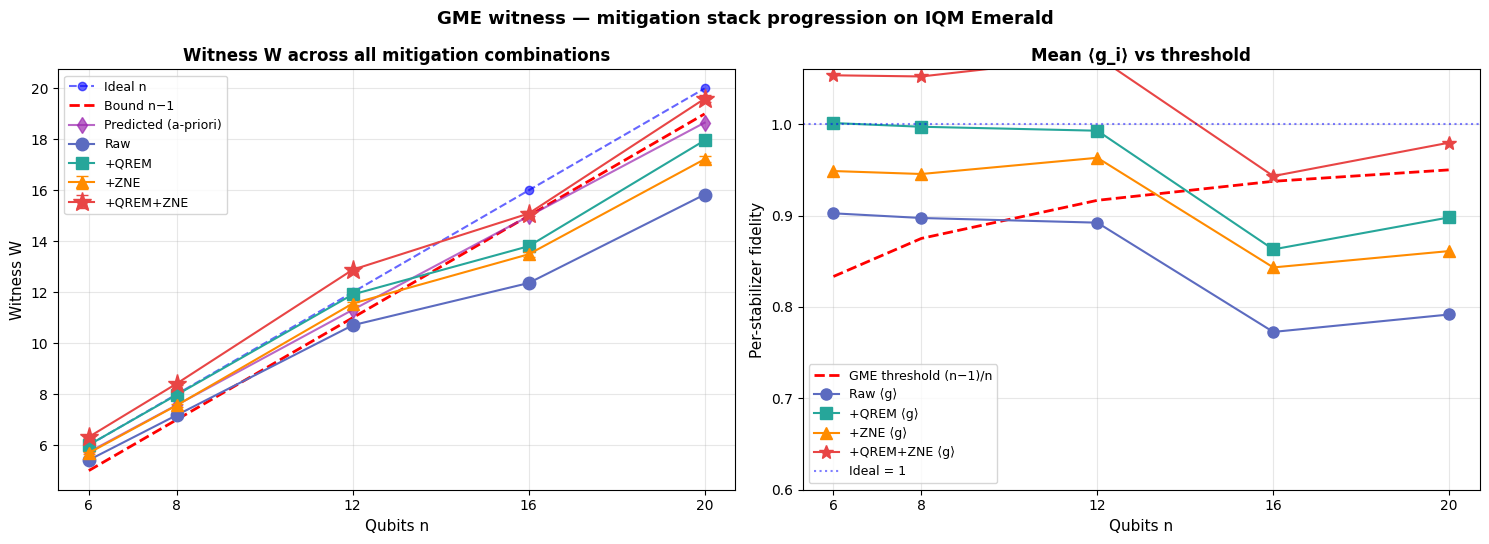

In [11]:
ns = [r['n'] for r in results]
ideal_arr = ns
bound_arr = [n-1 for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.plot(ns, ideal_arr, 'b--o', label='Ideal n', markersize=6, alpha=0.6)
ax.plot(ns, bound_arr, 'r--', linewidth=2, label='Bound n−1')
ax.plot(ns, [r['predicted_W'] for r in results], 'd-', color='#9c27b0',
        label='Predicted (a-priori)', markersize=8, alpha=0.7)
ax.plot(ns, [r['W_raw']  for r in results], 'o-', color='#5c6bc0', label='Raw',         markersize=9)
ax.plot(ns, [r['W_qrem'] for r in results], 's-', color='#26a69a', label='+QREM',       markersize=9)
ax.errorbar(ns, [r['W_zne'] for r in results],
            yerr=[r['W_zne_std'] for r in results],
            fmt='^-', color='#ff8b00', label='+ZNE',       markersize=9, capsize=4)
ax.errorbar(ns, [r['W_qz']  for r in results],
            yerr=[r['W_qz_std']  for r in results],
            fmt='*-', color='#e84545', label='+QREM+ZNE',  markersize=14, capsize=4)
ax.set_xlabel('Qubits n', fontsize=11)
ax.set_ylabel('Witness W', fontsize=11)
ax.set_title('Witness W across all mitigation combinations', fontweight='bold')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xticks(ns)

ax = axes[1]
ax.plot(ns, [(n-1)/n for n in ns], 'r--', linewidth=2, label='GME threshold (n−1)/n')
for key, label, color, marker in [
    ('W_raw',  'Raw ⟨g⟩',         '#5c6bc0', 'o'),
    ('W_qrem', '+QREM ⟨g⟩',       '#26a69a', 's'),
    ('W_zne',  '+ZNE ⟨g⟩',        '#ff8b00', '^'),
    ('W_qz',   '+QREM+ZNE ⟨g⟩',   '#e84545', '*'),
]:
    ax.plot(ns, [r[key]/r['n'] for r in results], f'{marker}-', color=color,
            label=label, markersize=10 if marker=='*' else 8)
ax.axhline(1.0, color='blue', linestyle=':', alpha=0.5, label='Ideal = 1')
ax.set_xlabel('Qubits n', fontsize=11)
ax.set_ylabel('Per-stabilizer fidelity', fontsize=11)
ax.set_title('Mean ⟨g_i⟩ vs threshold', fontweight='bold')
ax.set_xticks(ns); ax.set_ylim(0.6, 1.06); ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9)

plt.suptitle('GME witness — mitigation stack progression on IQM Emerald',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('showcase_pred_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()

## Per-qubit stabilizer values — raw vs +QREM (at scale = 1)

Map of ⟨g_i⟩ on the actual chip layout. Top row = raw measured at scale=1, bottom row = +QREM at scale=1. Tree edges are now correctly drawn between the highlighted qubits (the previous version of this notebook had a bug where logical edge indices were treated as physical).

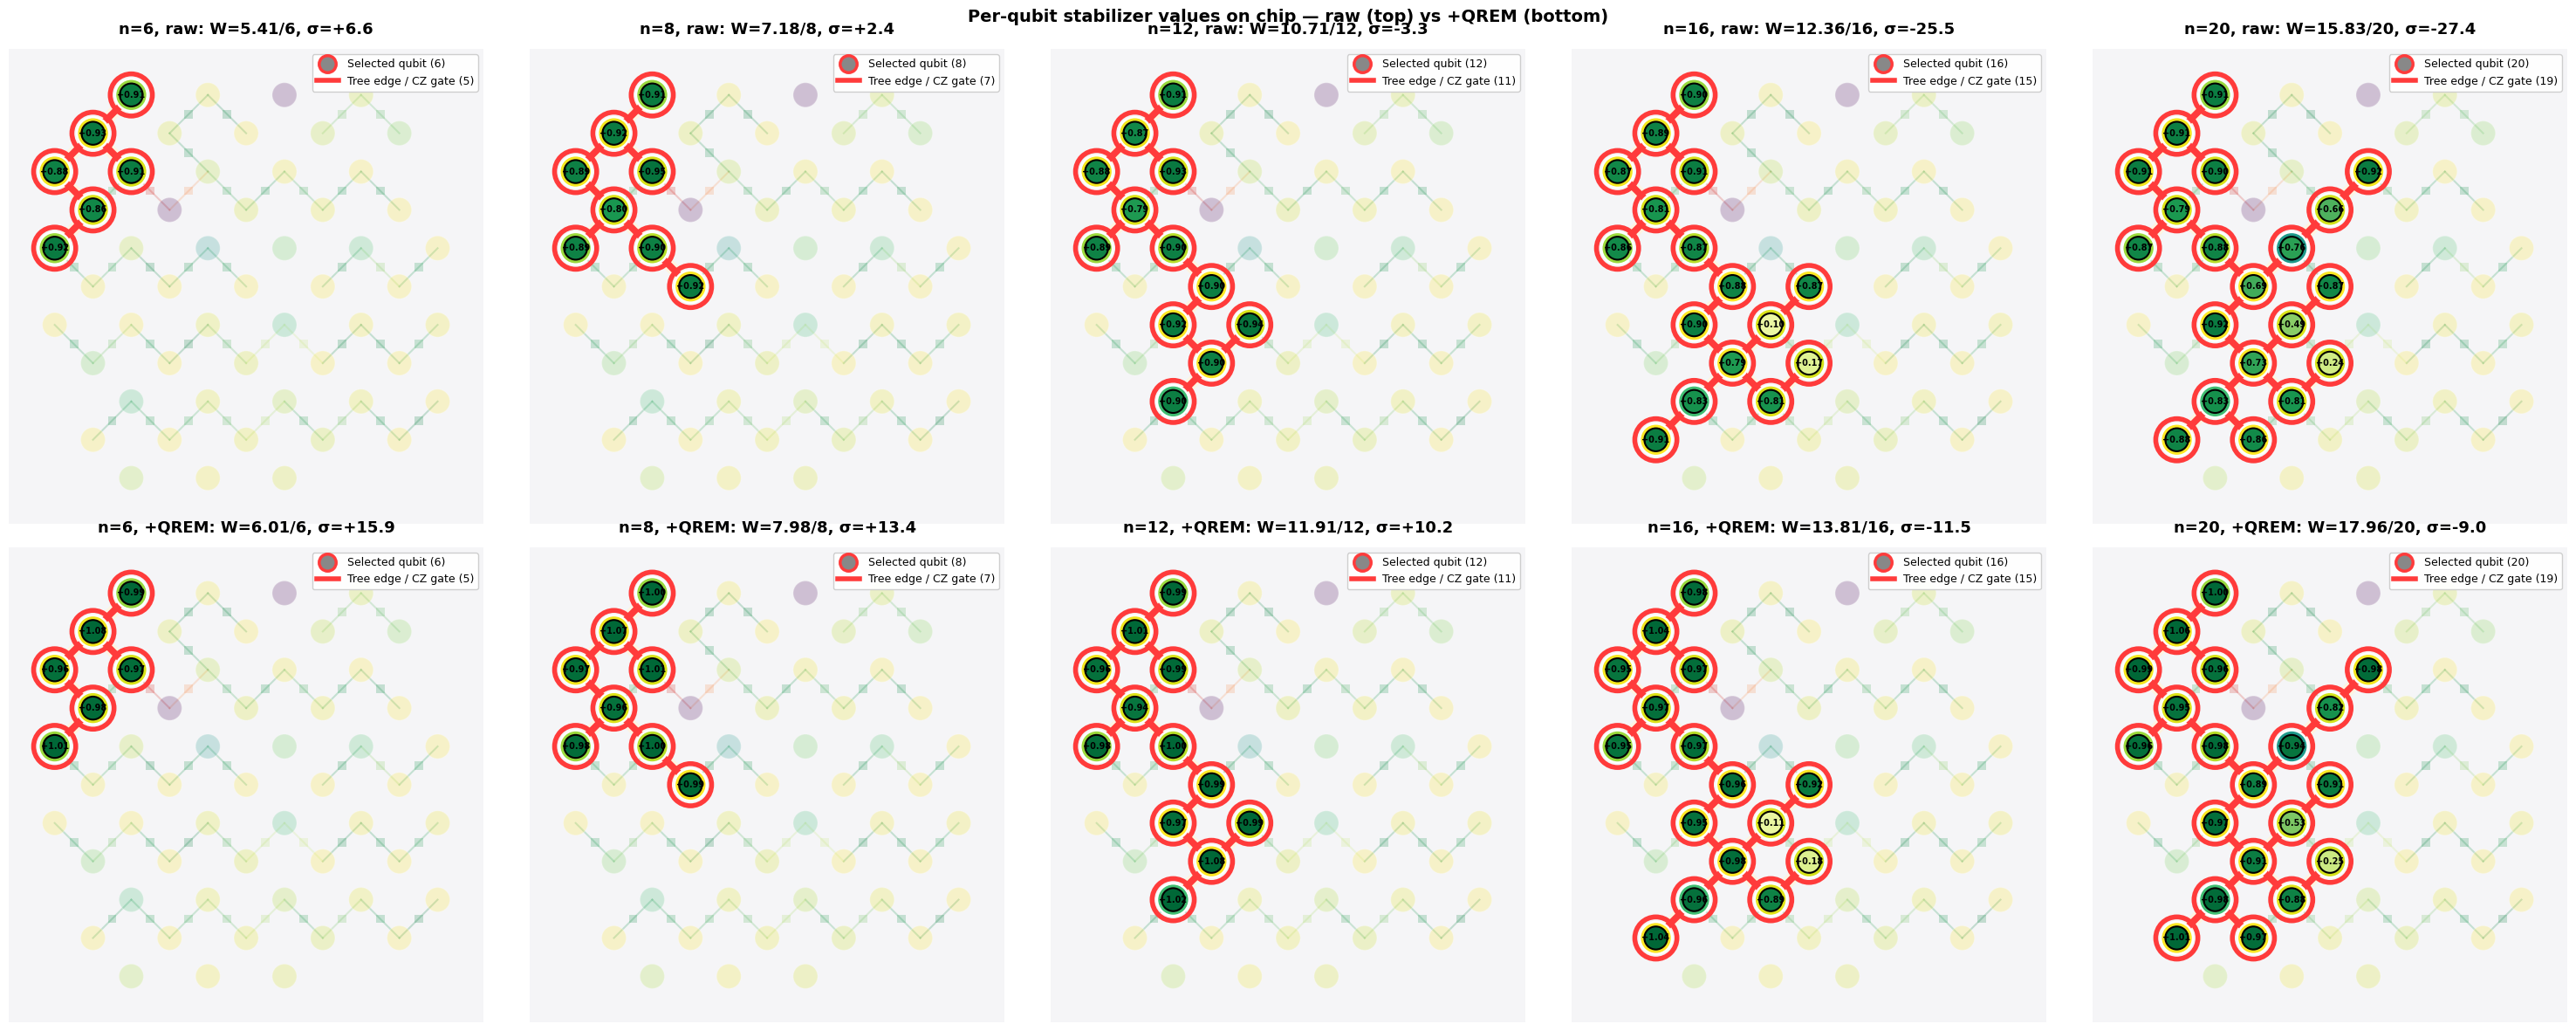

In [12]:
from matplotlib.cm import RdYlGn
import matplotlib.patches as mpatches

pos = _device_layout(backend)
fig, axes = plt.subplots(2, len(results), figsize=(6*len(results), 12), squeeze=False)

for col, r in enumerate(results):
    n = r['n']
    qubits = r['qubits']
    # Convert logical edges to physical edges for plotting
    phys_edges = [(qubits[a], qubits[b]) for a, b in r['logical_edges']]

    # Recompute per-qubit stabilizer values for scale=1, raw and +QREM
    cA = counts_by[(n, 1)]['a']; cB = counts_by[(n, 1)]['b']
    res_s = compute_gme_witness_graph(cA, cB, n, r['logical_edges'], r['coloring'])
    stab_raw = res_s['stabilizer_values']
    stab_qrem = apply_qrem_to_stabilizers_graph(
        stab_raw, n, r['logical_edges'], qubits, correction_factors)

    for row_idx, (stab, label, W_val, sigma_val) in enumerate([
        (stab_raw,  'raw',   r['W_raw'],  r['sigma_raw']),
        (stab_qrem, '+QREM', r['W_qrem'], r['sigma_qrem']),
    ]):
        ax = axes[row_idx, col]
        plot_device_topology(
            backend, metrics=qm, cz_fidelities=cz, color_by='readout_fidelity',
            highlight_qubits=qubits,
            highlight_edges=phys_edges,         # ← physical, not logical
            ax=ax, spotlight=True, show_labels=False, pos=pos,
            title=f"n={n}, {label}: W={W_val:.2f}/{n}, σ={sigma_val:+.1f}",
        )
        # Overlay per-qubit stabilizer values
        for lq, val in stab.items():
            pq = qubits[lq]
            x, y = pos[pq]
            color = RdYlGn((val + 1) / 2)
            ax.add_patch(mpatches.Circle((x, y), radius=0.30, facecolor=color,
                                          edgecolor='black', linewidth=1.5, zorder=15))
            ax.text(x, y, f'{val:+.2f}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='black', zorder=16)

plt.suptitle('Per-qubit stabilizer values on chip — raw (top) vs +QREM (bottom)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('showcase_heatmaps.png', dpi=110, bbox_inches='tight')
plt.show()

## Summary

In [13]:
print('=' * 60)
print('FINAL SUMMARY — IQM Emerald GME mitigation stack')
print('=' * 60)
for key, label in [('is_gme_raw', 'raw       '),
                    ('is_gme_qrem', '+QREM     '),
                    ('is_gme_zne', '+ZNE      '),
                    ('is_gme_qz',  '+QREM+ZNE ')]:
    m = max((r['n'] for r in results if r[key]), default=0)
    print(f'  Max n certified, {label}: {m} qubits')

print()
print('Predictor accuracy (predW vs measured +QREM W at scale=1):')
for r in results:
    err = r['W_qrem'] - r['predicted_W']
    print(f'  n={r["n"]:>2}: predicted {r["predicted_W"]:>5.2f}  →  measured {r["W_qrem"]:>5.2f}  '
          f'(error {err:+5.2f}, {abs(err)/r["n"]*100:>4.1f}% of n)')

import json
with open('showcase_results.json', 'w') as f:
    json.dump([
        {**r,
         'qubits': r['qubits'],
         'logical_edges': r['logical_edges'],
         'coloring': r['coloring'],
         'W_raw_per_scale': r['W_raw_per_scale'],
         'W_qrem_per_scale': r['W_qrem_per_scale'],
        } for r in results
    ], f, indent=2)
print('\nFull data saved to showcase_results.json')

FINAL SUMMARY — IQM Emerald GME mitigation stack
  Max n certified, raw       : 8 qubits
  Max n certified, +QREM     : 12 qubits
  Max n certified, +ZNE      : 12 qubits
  Max n certified, +QREM+ZNE : 20 qubits

Predictor accuracy (predW vs measured +QREM W at scale=1):
  n= 6: predicted  5.73  →  measured  6.01  (error +0.28,  4.6% of n)
  n= 8: predicted  7.58  →  measured  7.98  (error +0.40,  5.0% of n)
  n=12: predicted 11.31  →  measured 11.91  (error +0.60,  5.0% of n)
  n=16: predicted 14.99  →  measured 13.81  (error -1.18,  7.4% of n)
  n=20: predicted 18.66  →  measured 17.96  (error -0.70,  3.5% of n)

Full data saved to showcase_results.json
